Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv
Shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical  

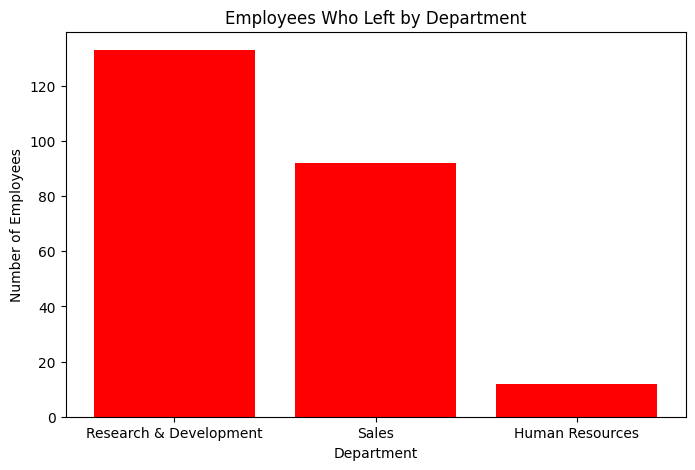

% who left per department:
Department
Research & Development    13.8
Sales                     20.6
Human Resources           19.0
Name: count, dtype: float64
OverTime
No     1054
Yes     416
Name: count, dtype: int64
% who left by overtime:
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64


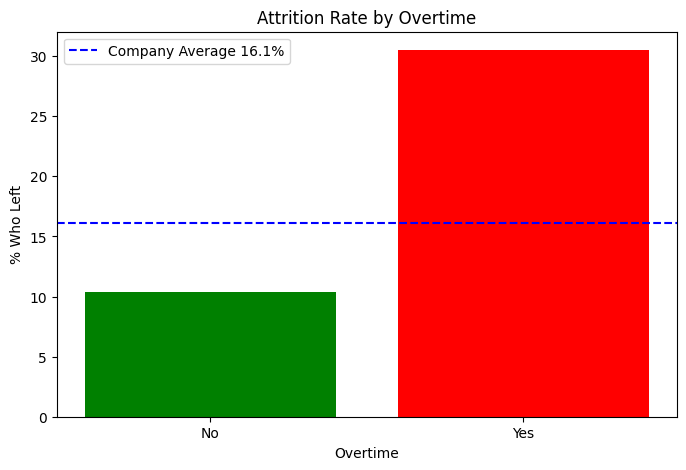

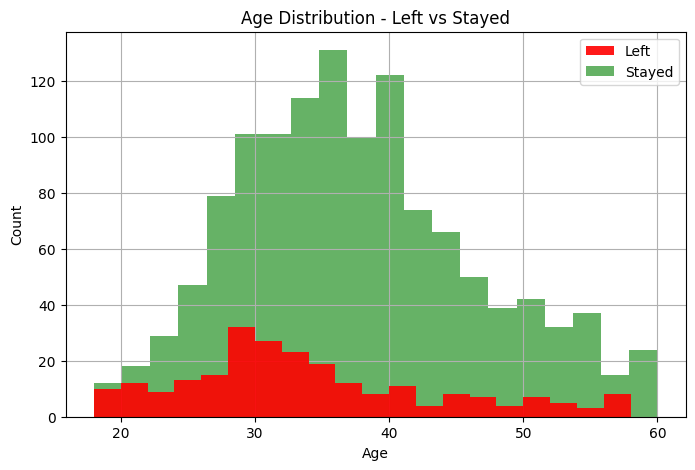

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Run this in Colab
from google.colab import files
uploaded = files.upload()  # opens file picker

import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())
print(df.isnull().sum())
print(df['Attrition'].value_counts())
left_dept = df[df['Attrition'] == 'Yes']['Department'].value_counts()
print(left_dept)

plt.figure(figsize=(8, 5))
plt.bar(left_dept.index, left_dept.values, color='red')
plt.title('Employees Who Left by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.show()
total_dept = df['Department'].value_counts()
left_dept = df[df['Attrition'] == 'Yes']['Department'].value_counts()
pct_left = (left_dept / total_dept * 100).round(1)
print("% who left per department:")
print(pct_left)

overtime = df[df['Attrition']== 'YES']['OverTime'].value_counts()
print(df['OverTime'].value_counts())
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print("% who left by overtime:")
print(overtime_attrition)

plt.figure(figsize=(8, 5))
plt.bar(overtime_attrition.index,
        overtime_attrition.values,
        color=['green', 'red'])
plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('% Who Left')
plt.axhline(y=16.1, color='blue',
            linestyle='--',
            label='Company Average 16.1%')
plt.legend()
plt.show()
plt.figure(figsize=(8, 5))
df[df['Attrition'] == 'Yes']['Age'].hist(bins=20, color='red', alpha=0.9, label='left', zorder=2)
df[df['Attrition'] == 'No']['Age'].hist(bins=20, color='green', alpha=0.6, label='stayed', zorder=1)
plt.title('Age Distribution - Left vs Stayed')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Left', 'Stayed'])
plt.show()
